In [32]:
import duckdb
import pandas as pd
import os
from dotenv import load_dotenv

# --- CONFIGURAÇÕES GLOBAIS DE AMBIENTE E FILTROS ---
load_dotenv()
data_inicio = os.getenv("DATA_INICIO")
data_fim = os.getenv("DATA_FIM")
curso_id = os.getenv("CURSO_ID")

usuarios_ignorados = "('0', '-1', '', 'nan', 'user6442803380426375169', 'user8540069828419911681')" 

filtro_curso_periodo = (
    f"(courseid = '{curso_id}' OR courseid = '0') AND "
    f"CAST(timecreated AS BIGINT) BETWEEN "
    f"epoch(TIMESTAMP '{data_inicio} 00:00:00') AND "
    f"epoch(TIMESTAMP '{data_fim} 23:59:59')"
)

print("🦆 Extraindo Logs de Interação (Cruzando com Módulos para achar as Seções)...")
pasta_dados = "export/" 

query_logs = f"""
    SELECT logs.timecreated, logs.username, logs.eventname, logs.action, 
           logs.component, logs.contextinstanceid, logs.courseid, cm.section AS section
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    LEFT JOIN read_csv_auto('{pasta_dados}mdl_course_modules.csv', ALL_VARCHAR=TRUE) AS cm
        ON logs.contextinstanceid = cm.id
    WHERE logs.username NOT IN {usuarios_ignorados}
      AND logs.username IS NOT NULL
      AND {filtro_curso_periodo}  
    ORDER BY CAST(logs.timecreated AS BIGINT) ASC
"""
df_logs = duckdb.query(query_logs).df()


def analisar_dataset_moodle(df):
    print("📊 --- RADIOGRAFIA DO CURSO 'TEACHING WITH MOODLE' --- 📊\n")
    
    # 1. Total de Eventos
    total_eventos = len(df)
    print(f"🔹 Total de Interações (Logs): {total_eventos:,}".replace(',', '.'))
    
    # 2. Total de Alunos Únicos
    alunos_validos = df[~df['username'].isin(['0', '-1', 'nan', 'None', ''])]
    total_alunos = alunos_validos['username'].nunique()
    print(f"👨‍🎓 Total de Alunos Únicos: {total_alunos:,}".replace(',', '.'))
    
    # 3. Total de Seções (Tópicos/Semanas do Curso)
    # Filtramos os nulos para contar apenas seções reais resultantes do JOIN
    secoes_validas = df[~df['section'].isin(['0', 'nan', 'None', '', None]) & df['section'].notna()]
    total_secoes = secoes_validas['section'].nunique()
    print(f"🗂️ Total de Seções (Tópicos do Curso): {total_secoes:,}".replace(',', '.'))
    
    # 4. Total de Atividades Únicas
    atividades_validas = df[~df['contextinstanceid'].isin(['0', 'nan', 'None', ''])]
    total_atividades = atividades_validas['contextinstanceid'].nunique()
    print(f"📝 Total de Instâncias (Atividades Diferentes): {total_atividades:,}".replace(',', '.'))
    
    print("\n🏆 --- TOP 5 EVENTOS MAIS COMUNS --- 🏆")
    top_eventos = df['eventname'].value_counts().head(5)
    for evento, qtd in top_eventos.items():
        # Limpa o nome do evento para ficar mais legível no notebook
        nome_limpo = str(evento).replace('\\', ' > ').strip(' > ')
        print(f"   - {nome_limpo}: {qtd:,}".replace(',', '.'))
        
    print("\n🧩 --- TOP 5 COMPONENTES MAIS ACESSADOS --- 🧩")
    top_componentes = df['component'].value_counts().head(5)
    for comp, qtd in top_componentes.items():
        print(f"   - {str(comp).replace('mod_', '').title()}: {qtd:,}".replace(',', '.'))

# Executa a análise no DataFrame isolado com a coluna section real
analisar_dataset_moodle(df_logs)

🦆 Extraindo Logs de Interação (Cruzando com Módulos para achar as Seções)...
📊 --- RADIOGRAFIA DO CURSO 'TEACHING WITH MOODLE' --- 📊

🔹 Total de Interações (Logs): 846.983
👨‍🎓 Total de Alunos Únicos: 2.158
🗂️ Total de Seções (Tópicos do Curso): 6
📝 Total de Instâncias (Atividades Diferentes): 2.326

🏆 --- TOP 5 EVENTOS MAIS COMUNS --- 🏆
   - core > event > webservice_function_called: 139.959
   - core > event > course_viewed: 92.367
   - core > event > message_viewed: 82.551
   - core > event > message_sent: 74.304
   - mod_book > event > chapter_viewed: 67.772

🧩 --- TOP 5 COMPONENTES MAIS ACESSADOS --- 🧩
   - Core: 494.227
   - Forum: 118.052
   - Book: 80.538
   - Quiz: 39.377
   - Page: 27.324


In [33]:
import duckdb

query_cursos_reais = fquery_logs = f"""
        SELECT logs.timecreated, logs.username, logs.eventname, logs.action, 
            logs.component, logs.contextinstanceid, logs.courseid, cm.section AS section
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    LEFT JOIN read_csv_auto('{pasta_dados}mdl_course_modules.csv', ALL_VARCHAR=TRUE) AS cm
        ON logs.contextinstanceid = cm.id
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') AND logs.username IS NOT NULL
    AND {filtro_curso_periodo}
    ORDER BY CAST(logs.timecreated AS BIGINT) ASC
"""
df_cursos = duckdb.query(query_cursos_reais).df()


In [34]:
quantas_complecoes = f"""
    SELECT 
        COUNT(DISTINCT logs.id) as qtd_complecoes
    FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE) AS logs
    WHERE logs.username NOT IN ('0', '-1', '', 'nan') 
      AND {filtro_curso_periodo}
      AND logs.eventname = '\\mod_quiz\\event\\attempt_submitted'
      AND logs.contextinstanceid = '54994'
    GROUP BY logs.courseid
"""

df_cursos = duckdb.query(quantas_complecoes).df()
display(df_cursos)

,qtd_complecoes
0,1762


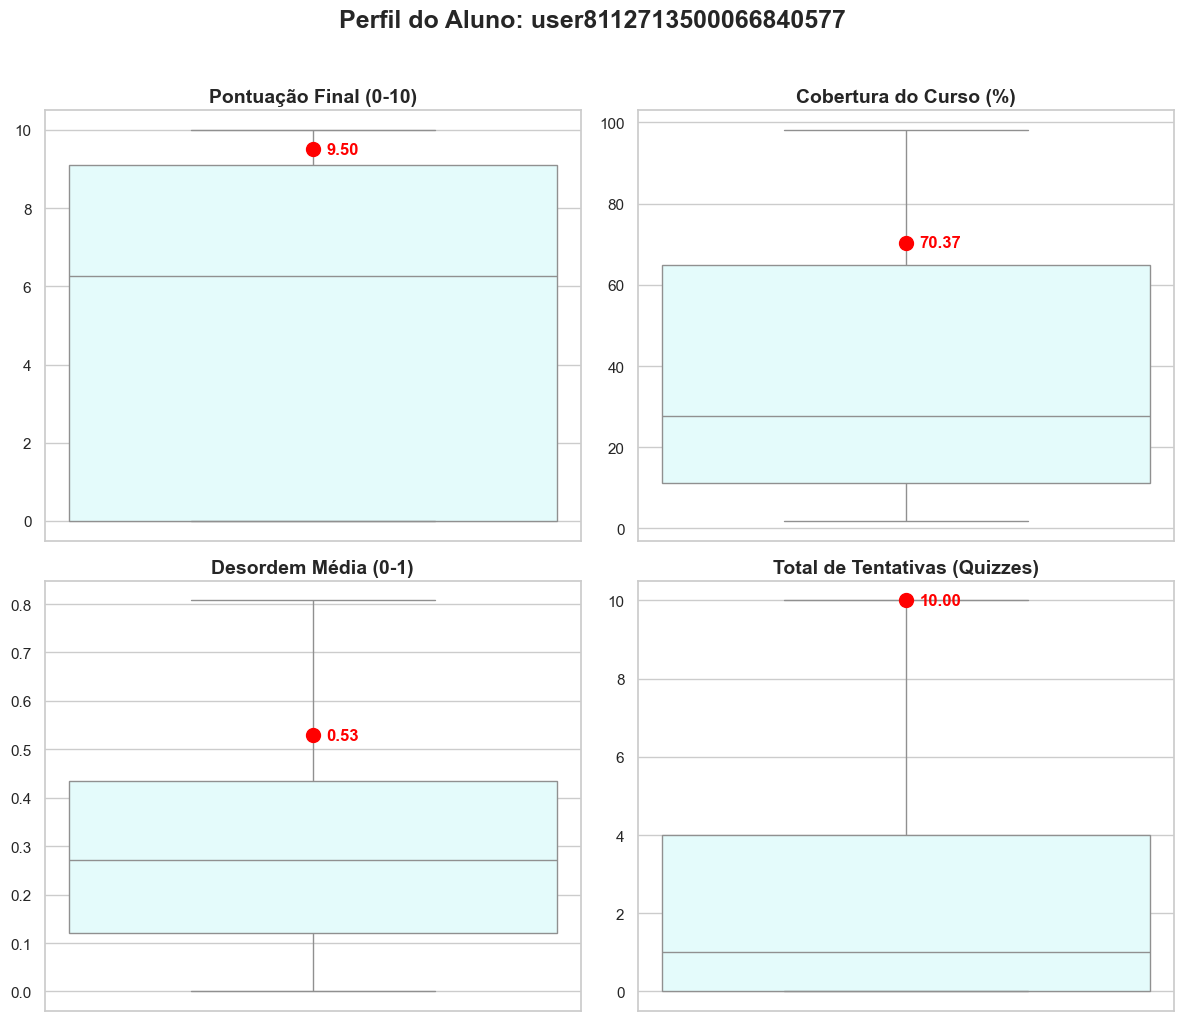

In [35]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente
load_dotenv(override=True)

# Puxa o caminho da pasta de dados do arquivo .env
export_path = os.getenv("PASTA_DADOS")

# Definição dinâmica dos caminhos
atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_em_visitas_reais_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# Configuração visual do gráfico
sns.set_theme(style="whitegrid")

def gerar_boxplot_aluno(aluno_alvo):
    # ==========================================
    # 1. CARREGAMENTO E EXTRAÇÃO DAS MÉTRICAS
    # ==========================================
    
    # 1.1 Pontuação
    with open(pontuacao_path, 'r', encoding='utf-8') as f:
        pont_data = json.load(f)
    df_pont = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
    
    # 1.2 Porcentagem do Curso Acessada
    with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
        perc_data = json.load(f)
    records_perc = []
    for user, data in perc_data.get('Course 10464', {}).items():
        records_perc.append({'usuario': user, 'porcentagem_acessada': data.get('geral', 0)})
    df_perc = pd.DataFrame(records_perc)
    
    # 1.3 Nível de Desordem (Calculando a média das sessões do aluno)
    with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
        desordem_data = json.load(f)
    desordem_records = {}
    for sessao, s_data in desordem_data.get('Course 10464', {}).get('sessoes', {}).items():
        usuarios = s_data.get('nivel_desordem_por_usuario', {})
        for u, val in usuarios.items():
            desordem_records.setdefault(u, []).append(val)
    df_desordem = pd.DataFrame([
        {'usuario': u, 'desordem_media': sum(vals)/len(vals)} 
        for u, vals in desordem_records.items()
    ])
    
    # 1.4 Tentativas por Questionário (Somando o total do aluno)
    with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
        tentativas_data = json.load(f)
    df_tentativas = pd.DataFrame(tentativas_data)
    df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()

    # ==========================================
    # 2. MERGE (UNINDO TODAS AS MÉTRICAS)
    # ==========================================
    df_final = df_pont.merge(df_perc, on='usuario', how='outer')\
                      .merge(df_desordem, on='usuario', how='outer')\
                      .merge(df_tentativas, on='usuario', how='outer')
    
    # Preenche com 0 caso o aluno não tenha registro em alguma métrica
    df_final = df_final.fillna(0)

    # ==========================================
    # 3. GERAÇÃO DOS BOX PLOTS
    # ==========================================
    # Define as métricas e seus respectivos títulos de forma pareada
    configuracoes = [
        ('pontuacao', 'Pontuação Final (0-10)'),
        ('porcentagem_acessada', 'Cobertura do Curso (%)'),
        ('desordem_media', 'Desordem Média (0-1)'),
        ('total_tentativas', 'Total de Tentativas (Quizzes)')
    ]

    # Cria o grid 2x2: figsize=(largura, altura) aumentado para dar espaço
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f"Perfil do Aluno: {aluno_alvo}", fontsize=18, fontweight='bold', y=1.02)

    # Achata a matriz de eixos para iterar facilmente (de 2x2 para [ax1, ax2, ax3, ax4])
    axes_flat = axes.flatten()

    aluno_existe = aluno_alvo in df_final['usuario'].values

    for i, (metrica, titulo) in enumerate(configuracoes):
        ax = axes_flat[i]
        
        # Desenha o Box Plot da turma
        sns.boxplot(y=df_final[metrica], ax=ax, color='lightcyan', width=0.4, showfliers=False)
        
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_ylabel("")
        
        # Destaca o aluno alvo se ele existir nos dados
        if aluno_existe:
            valor_alvo = df_final[df_final['usuario'] == aluno_alvo][metrica].values[0]
            # Ponto vermelho no gráfico
            ax.plot(0, valor_alvo, marker='o', color='red', markersize=10, zorder=10)
            # Anotação com o valor ao lado do ponto
            ax.annotate(f'{valor_alvo:.2f}', 
                        xy=(0, valor_alvo), 
                        xytext=(10, 0), 
                        textcoords='offset points', 
                        color='red', 
                        weight='bold', 
                        fontsize=12,
                        va='center')

    # Ajusta o layout para evitar sobreposição e salvar em alta qualidade
    plt.tight_layout()

    # Salva a imagem para o seu documento (DPI 300 para qualidade acadêmica)
    plt.savefig(os.path.join(export_path, "resultado.png"), dpi=300, bbox_inches='tight')

    plt.show()

# Chama a função
gerar_boxplot_aluno("user8112713500066840577")

📥 Extraindo métricas...
🔄 Unindo bases de dados...
✅ Imagem salva com sucesso em: export\resultado.png


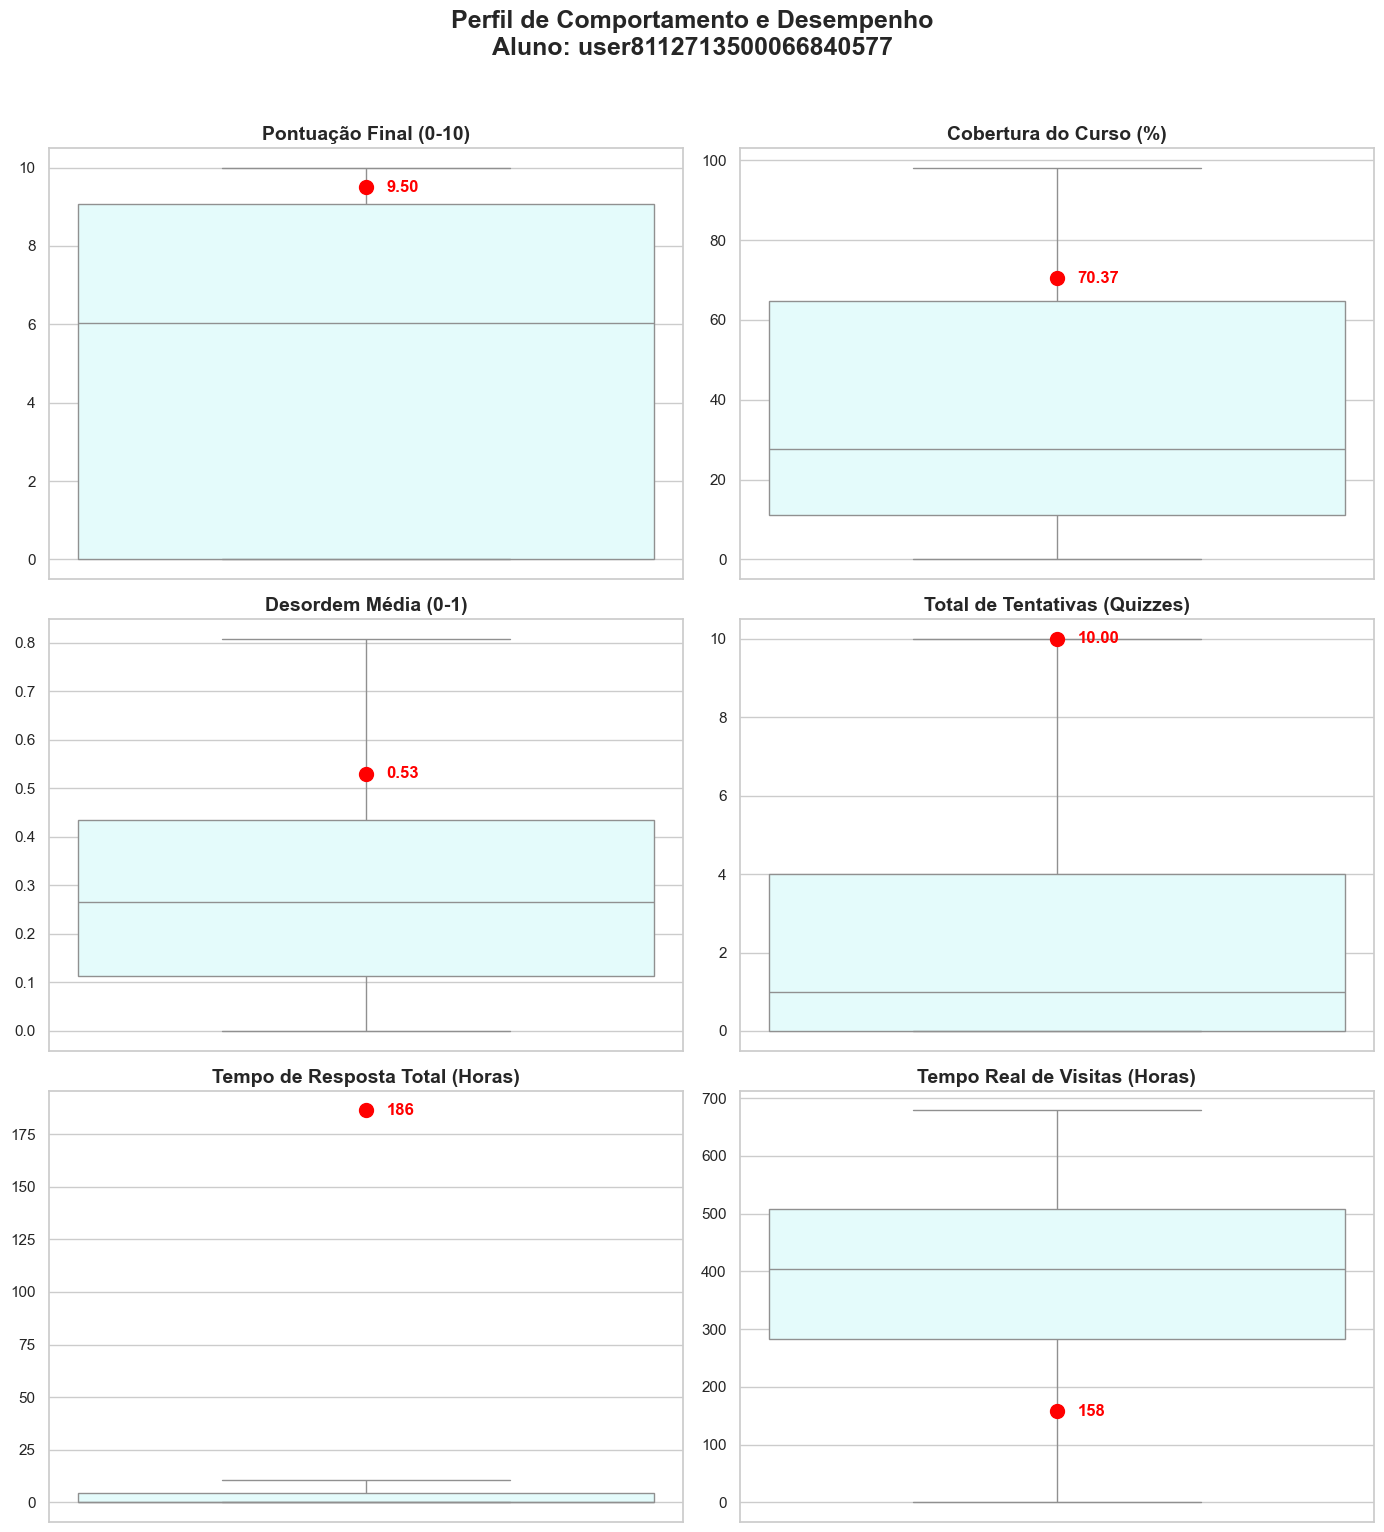


--- Tabela de Valores do Aluno Alvo ---


,usuario,pontuacao,porcentagem_acessada,desordem_media,total_tentativas,soma_tempo_resposta_horas,soma_tempo_total_horas
1847,user8112713500066840577,9.5,70.37,0.52942,10.0,186.235556,157.754444


In [36]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os
from functools import reduce
from dotenv import load_dotenv

# ==========================================
# 0. CONFIGURAÇÕES INICIAIS
# ==========================================
load_dotenv(override=True)
export_path = os.getenv("PASTA_DADOS", "export/")
sns.set_theme(style="whitegrid")

# ==========================================
# 1. FUNÇÕES DE EXTRAÇÃO DE MÉTRICAS
# ==========================================

def extrair_pontuacao(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return pd.DataFrame(data)[['usuario', 'pontuacao']]

def extrair_porcentagem(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records = [{'usuario': user, 'porcentagem_acessada': d.get('geral', 0)} 
               for user, d in data.get('Course 10464', {}).items()]
    return pd.DataFrame(records)

def extrair_desordem(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    records = {}
    for sessao, s_data in data.get('Course 10464', {}).get('sessoes', {}).items():
        for u, val in s_data.get('nivel_desordem_por_usuario', {}).items():
            records.setdefault(u, []).append(val)
    return pd.DataFrame([
        {'usuario': u, 'desordem_media': sum(vals)/len(vals)} 
        for u, vals in records.items()
    ])

def extrair_tentativas(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    return df.groupby('usuario')['total_tentativas'].sum().reset_index()

def extrair_tempo_resposta(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    
    # Regex para extrair Dias, Horas, Minutos e Segundos do formato ISO (PT1M30S)
    regex = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    extraido = df['tempo_resposta'].str.extract(regex).fillna(0).astype(int)
    
    # Converte tudo para segundos inteiros
    df['tempo_resposta_horas'] = (extraido[0]*86400 + extraido[1]*3600 + extraido[2]*60 + extraido[3]) / 3600.0
    # Soma o tempo de todas as atividades por usuário
    df_agrupado = df.groupby('usuario')['tempo_resposta_horas'].sum().reset_index()
    return df_agrupado.rename(columns={'tempo_resposta_horas': 'soma_tempo_resposta_horas'})

def extrair_tempo_real(caminho):
    with open(caminho, 'r', encoding='utf-8') as f:
        data = json.load(f)
    df = pd.DataFrame(data)
    
    regex = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
    extraido = df['tempo_passado'].str.extract(regex).fillna(0).astype(int)
    
    # Calcula os segundos e divide por 3600 para transformar em HORAS decimais
    df['tempo_passado_horas'] = (extraido[0]*86400 + extraido[1]*3600 + extraido[2]*60 + extraido[3]) / 3600.0
    
    # Soma o tempo real de visitas (agora em horas)
    df_agrupado = df.groupby('usuario')['tempo_passado_horas'].sum().reset_index()
    
    # Renomeia a coluna para refletir a nova unidade de medida
    return df_agrupado.rename(columns={'tempo_passado_horas': 'soma_tempo_total_horas'})

# ==========================================
# 2. FUNÇÃO PRINCIPAL DE GERAÇÃO DO GRÁFICO
# ==========================================

def gerar_boxplot_aluno(aluno_alvo):
    # Definindo caminhos
    caminhos = {
        'pontuacao': os.path.join(export_path, "pontuacao.json"),
        'porcentagem': os.path.join(export_path, "porcentagem_curso_acessada.json"),
        'desordem': os.path.join(export_path, "nivel_desordem.json"),
        'tentativas': os.path.join(export_path, "tentativas_por_questionario.json"),
        'tempo_resp': os.path.join(export_path, "tempo_resposta.json"),
        'tempo_real': os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")
    }

    print("📥 Extraindo métricas...")
    dfs = [
        extrair_pontuacao(caminhos['pontuacao']),
        extrair_porcentagem(caminhos['porcentagem']),
        extrair_desordem(caminhos['desordem']),
        extrair_tentativas(caminhos['tentativas']),
        extrair_tempo_resposta(caminhos['tempo_resp']),
        extrair_tempo_real(caminhos['tempo_real'])
    ]

    print("🔄 Unindo bases de dados...")
    # Une todos os DataFrames pelo 'usuario'
    df_final = reduce(lambda left, right: pd.merge(left, right, on='usuario', how='outer'), dfs)
    df_final = df_final.fillna(0)

    # Configurações do Grid 3x2
    configuracoes = [
        ('pontuacao', 'Pontuação Final (0-10)'),
        ('porcentagem_acessada', 'Cobertura do Curso (%)'),
        ('desordem_media', 'Desordem Média (0-1)'),
        ('total_tentativas', 'Total de Tentativas (Quizzes)'),
        ('soma_tempo_resposta_horas', 'Tempo de Resposta Total (Horas)'),
        ('soma_tempo_total_horas', 'Tempo Real de Visitas (Horas)')
    ]

    # Criação do grid 3x2 (aumentado a altura para acomodar 3 linhas)
    fig, axes = plt.subplots(3, 2, figsize=(14, 15))
    fig.suptitle(f"Perfil de Comportamento e Desempenho\nAluno: {aluno_alvo}", fontsize=18, fontweight='bold', y=1.02)

    axes_flat = axes.flatten()
    aluno_existe = aluno_alvo in df_final['usuario'].values

    for i, (metrica, titulo) in enumerate(configuracoes):
        ax = axes_flat[i]
        
        sns.boxplot(y=df_final[metrica], ax=ax, color='lightcyan', width=0.4, showfliers=False)
        ax.set_title(titulo, fontsize=14, fontweight='bold')
        ax.set_ylabel("")
        
        if aluno_existe:
            valor_alvo = df_final[df_final['usuario'] == aluno_alvo][metrica].values[0]
            ax.plot(0, valor_alvo, marker='o', color='red', markersize=10, zorder=10)
            ax.annotate(f'{valor_alvo:.0f}' if 'tempo' in metrica else f'{valor_alvo:.2f}', 
                        xy=(0, valor_alvo), 
                        xytext=(15, 0), 
                        textcoords='offset points', 
                        color='red', weight='bold', fontsize=12, va='center')

    plt.tight_layout()
    
    # Exporta a imagem para a pasta export_path
    caminho_imagem = os.path.join(export_path, "resultado.png")
    plt.savefig(caminho_imagem, dpi=300, bbox_inches='tight')
    print(f"✅ Imagem salva com sucesso em: {caminho_imagem}")

    plt.show()

    if aluno_existe:
        print("\n--- Tabela de Valores do Aluno Alvo ---")
        display(df_final[df_final['usuario'] == aluno_alvo])
    else:
        print(f"⚠️ Atenção: O usuário {aluno_alvo} não foi encontrado nas métricas.")

# ==========================================
# 3. EXECUÇÃO
# ==========================================
gerar_boxplot_aluno("user8112713500066840577")

In [37]:
def extrair_notas_medias_normalizadas(pasta_dados="export/"):
    """
    Extrai a nota mais recente de cada atividade e a sua respectiva nota máxima (rawgrademax)
    diretamente da tabela de histórico, calculando a média final normalizada (0 a 1).
    """
    query_notas = f"""
        WITH NotasRecentes AS (
            SELECT 
                username,
                itemid,
                arg_max(CAST(finalgrade AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_recente,
                arg_max(CAST(rawgrademax AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_maxima
            FROM read_csv_auto('{pasta_dados}mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL
              AND rawgrademax NOT IN ('', 'nan', 'None') AND rawgrademax IS NOT NULL
              AND username NOT IN ('0', '-1', '', 'nan')
            GROUP BY username, itemid
        ),
        NotasNormalizadas AS (
            -- Calcular a proporção (0 a 1) para cada atividade
            SELECT 
                username,
                itemid,
                CASE 
                    WHEN nota_maxima > 0 THEN nota_recente / nota_maxima 
                    ELSE 0.0 
                END AS nota_item_0_a_1
            FROM NotasRecentes
        )
        -- Calcular a média geral final do aluno
        SELECT 
            username,
            AVG(nota_item_0_a_1) AS nota_media_normalizada
        FROM NotasNormalizadas
        GROUP BY username
        ORDER BY nota_media_normalizada DESC
    """
    
    # Executa a query e retorna o DataFrame
    return duckdb.query(query_notas).df()

# Executa a função
df_target_oficial = extrair_notas_medias_normalizadas()

df_target_oficial.head(5)

,username,nota_media_normalizada
0,user1082015833682608129,1.0
1,user3318166135160963073,1.0
2,user8363818986365779969,1.0
3,user3121616921183649793,1.0
4,user3876331387640348673,1.0


In [38]:
def analisar_engajamento_quizzes(pasta_dados="export/"):
    """
    Analisa os logs do Moodle para categorizar os alunos com base 
    na quantidade de quizzes distintos que eles acessaram/fizeram.
    """
    query_quizzes = f"""
        WITH TotalQuizzes AS (
            -- Passo 1: Descobre o número total de quizzes únicos no curso
            -- O contextinstanceid identifica unicamente a instância de uma atividade
            SELECT COUNT(DISTINCT contextinstanceid) AS total_quizzes
            FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
            WHERE component = 'mod_quiz' AND contextlevel = '70' AND {filtro_curso_periodo}
        ),
        TodosUsuarios AS (
            -- Passo 2: Lista todos os alunos que acessaram o ambiente
            SELECT DISTINCT username 
            FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
            WHERE username NOT IN ('0', '-1', '', 'nan') AND username IS NOT NULL AND {filtro_curso_periodo}
        ),
        QuizzesPorUsuario AS (
            -- Passo 3: Conta quantos quizzes únicos cada aluno acessou/fez
            SELECT 
                username, 
                COUNT(DISTINCT contextinstanceid) AS quizzes_feitos
            FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
            WHERE component = 'mod_quiz' 
              AND username NOT IN ('0', '-1', '', 'nan') AND username IS NOT NULL AND {filtro_curso_periodo}
            GROUP BY username
        ),
        Engajamento AS (
            -- Passo 4: Une os dados e calcula a porcentagem exata para cada aluno
            SELECT 
                t.username,
                COALESCE(q.quizzes_feitos, 0) AS quizzes_feitos,
                (SELECT total_quizzes FROM TotalQuizzes) AS total_quizzes,
                CASE 
                    WHEN (SELECT total_quizzes FROM TotalQuizzes) > 0 
                    THEN (CAST(COALESCE(q.quizzes_feitos, 0) AS FLOAT) / (SELECT total_quizzes FROM TotalQuizzes)) * 100 
                    ELSE 0 
                END AS porcentagem
            FROM TodosUsuarios t
            LEFT JOIN QuizzesPorUsuario q ON t.username = q.username
        )
        -- Passo 5: Agrupa os alunos nas categorias solicitadas e faz a contagem
        SELECT 
            CASE 
                WHEN porcentagem = 0 THEN '1. Nenhum Quiz (0%)'
                WHEN porcentagem > 0 AND porcentagem < 50 THEN '2. Menos da Metade (1% a 49%)'
                WHEN porcentagem >= 50 AND porcentagem < 100 THEN '3. Metade ou Mais (50% a 99%)'
                WHEN porcentagem = 100 THEN '4. Todos os Quizzes (100%)'
            END AS categoria_engajamento,
            COUNT(username) AS total_alunos
        FROM Engajamento
        GROUP BY 1
        ORDER BY 1
    """
    
    # Executa a query e retorna o resultado
    return duckdb.query(query_quizzes).df()

# Executa e exibe o painel de categorias
df_engajamento = analisar_engajamento_quizzes()

display(df_engajamento)

,categoria_engajamento,total_alunos
0,1. Nenhum Quiz (0%),860
1,2. Menos da Metade (1% a 49%),559
2,3. Metade ou Mais (50% a 99%),495
3,4. Todos os Quizzes (100%),240
4,NaN,6


In [39]:
def diagnosticar_falsos_professores(pasta_dados="export/"):
    """
    Lista quais eventos acionaram o edulevel = 1 (Teaching) e quantas 
    pessoas diferentes executaram cada um.
    """
    print("🕵️‍♂️ Diagnosticando os eventos de Ensino (edulevel = 1)...")
    
    query = f"""
        SELECT 
            component,
            eventname,
            action,
            COUNT(DISTINCT username) AS total_pessoas,
            COUNT(*) AS total_de_logs
        FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
        WHERE courseid = '10464' 
          AND edulevel = '1'
          AND username NOT IN ('0', '-1', '', 'nan') AND username IS NOT NULL
        GROUP BY component, eventname, action
        ORDER BY total_pessoas DESC
    """
    
    return duckdb.query(query).df()

# Executa e exibe o diagnóstico
df_diagnostico_professores = diagnosticar_falsos_professores()
df_diagnostico_professores.to_csv(os.path.join(export_path, "diagnostico_professores.csv"), index=False)
display(df_diagnostico_professores)

🕵️‍♂️ Diagnosticando os eventos de Ensino (edulevel = 1)...


,component,eventname,action,total_pessoas,total_de_logs
0,mod_quiz,\mod_quiz\event\attempt_summary_viewed,viewed,1185,5787
1,core,\core\event\user_graded,graded,1179,26778
2,mod_quiz,\mod_quiz\event\attempt_reviewed,reviewed,1175,5978
3,core,\core\event\competency_evidence_created,created,1175,8990
4,core,\core\event\badge_awarded,awarded,1027,2097
5,report_outline,\report_outline\event\report_viewed,viewed,11,112
6,report_stats,\report_stats\event\user_report_viewed,viewed,4,5
7,core,\core\event\course_updated,updated,2,22
8,core,\core\event\course_module_created,created,2,28
9,mod_assign,\mod_assign\event\grading_table_viewed,viewed,2,140


In [40]:
import duckdb
import pandas as pd

def identificar_equipe_docente(pasta_dados="export/"):
    """
    Investiga os logs do curso para identificar os professores (facilitadores)
    e tentar encontrar quem executou a ação de criação do curso.
    """
    print("🕵️‍♂️ Investigando a autoria e a equipe docente do curso...")
    
    query = f"""
        WITH LogsCurso AS (
            SELECT username, eventname, action, target, edulevel
            FROM read_csv_auto('{pasta_dados}mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
            WHERE 
              username NOT IN ('0', '-1', '', 'nan') 
              AND username IS NOT NULL
              AND courseid = '{curso_id}'
        ),
        
        -- 1. Busca por quem disparou o evento de criação do curso (se estiver nos logs)
        Criador AS (
            SELECT DISTINCT 
                username, 
                'Criador do Curso (Course Creator)' AS papel
            FROM LogsCurso
            WHERE target = 'course' AND action = 'created'
               OR eventname LIKE '%course_created%'
        ),
        
        -- 2. Busca por quem tem ações de nível 1 (Teaching / Professor)
        Professores AS (
            SELECT DISTINCT 
                username, 
                'Professor' AS papel
            FROM LogsCurso
            WHERE edulevel = '1'
            AND eventname IN (
              '\\core\\event\\course_module_updated', 
              '\\core\\event\\course_module_created', 
              '\\core\\event\\course_section_updated',
              '\\core\\event\\course_updated'
            )
        )
        
        -- Une os resultados
        SELECT * FROM Criador
        UNION
        SELECT * FROM Professores
        ORDER BY papel DESC, username
    """
    
    df_equipe = duckdb.query(query).df()
    return df_equipe

# Executa a investigação
df_equipe_docente = identificar_equipe_docente()
display(df_equipe_docente)

🕵️‍♂️ Investigando a autoria e a equipe docente do curso...


,username,papel
0,user6442803380426375169,Professor
1,user8540069828419911681,Professor
